# Week 1 - Workshop + Worksheet

## Workshop 1

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image



g_path =  './lena_gray.gif'
c_path = './cameraman.png'

print('gray:', g_path)
print('img:', c_path)


gray: ./lena_gray.gif
img: ./cameraman.png


### Image processing steps

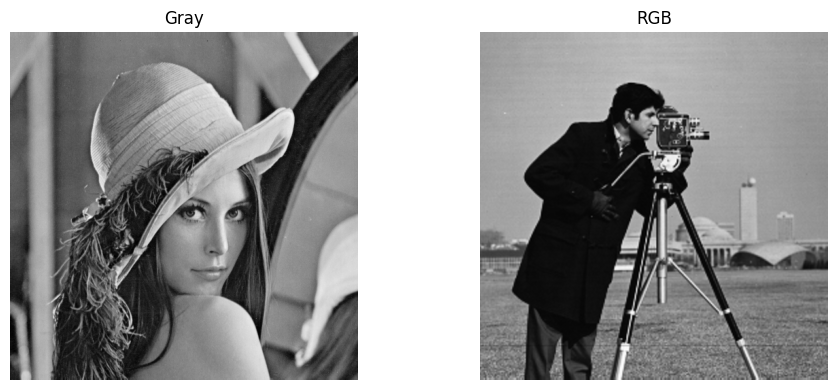

In [2]:
g_img = Image.open(g_path).convert('L')
c_img = Image.open(c_path).convert('RGB')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(g_img, cmap='gray')
plt.title('Gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(c_img)
plt.title('RGB')
plt.axis('off')

plt.tight_layout()
plt.show()


In [17]:
print('g fmt:', g_img.format)
print('g size:', g_img.size)
print('g mode:', g_img.mode)

print('c fmt:', c_img.format)
print('c size:', c_img.size)
print('c mode:', c_img.mode)

g_w, g_h = g_img.size
g_ch = len(g_img.getbands())
print('g shp:', (g_h, g_w, g_ch))
print('g pix:', g_w * g_h)

c_w, c_h = c_img.size
c_ch = len(c_img.getbands())
print('c shp:', (c_h, c_w, c_ch))
print('c val:', c_w * c_h * c_ch)


g fmt: None
g size: (512, 512)
g mode: L
c fmt: None
c size: (512, 512)
c mode: RGB
g shp: (512, 512, 1)
g pix: 262144
c shp: (512, 512, 3)
c val: 786432


c arr: (512, 512, 3)
g arr: (512, 512)


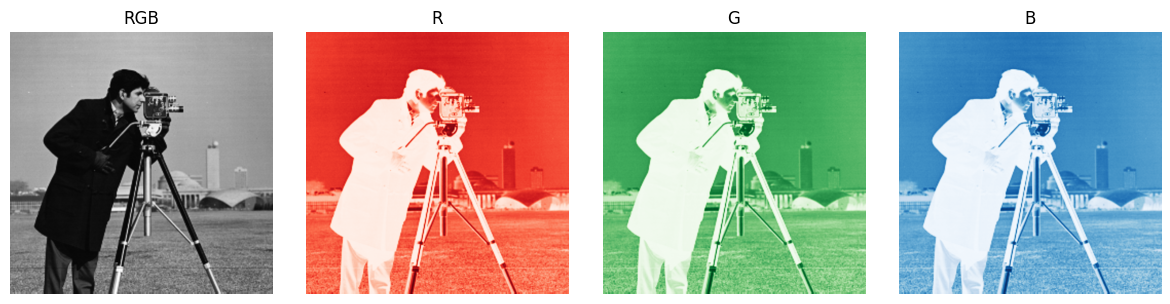

In [18]:
c_arr = np.array(c_img)
g_arr = np.array(g_img)

print('c arr:', c_arr.shape)
print('g arr:', g_arr.shape)

r = c_arr[:, :, 0]
g = c_arr[:, :, 1]
b = c_arr[:, :, 2]

plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
plt.imshow(c_arr)
plt.title('RGB')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(r, cmap='Reds')
plt.title('R')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(g, cmap='Greens')
plt.title('G')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(b, cmap='Blues')
plt.title('B')
plt.axis('off')

plt.tight_layout()
plt.show()


row: (512, 3)
col: (512, 3)
px: [153 153 153]


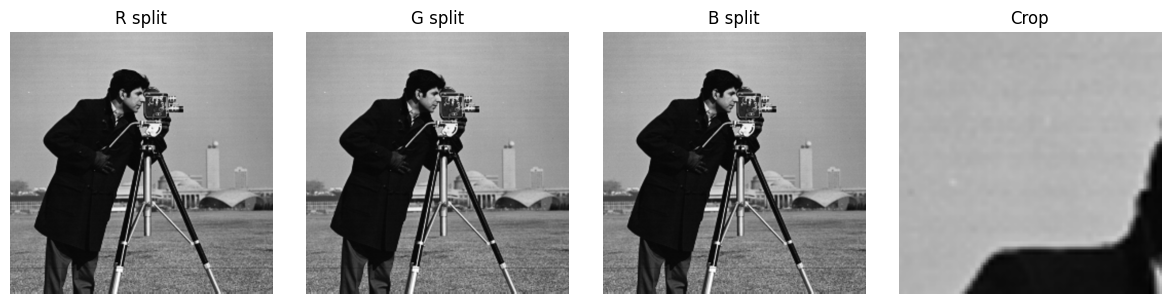

In [19]:
r_p, g_p, b_p = c_img.split()

row = c_arr[100, :, :]
col = c_arr[:, 50, :]
px = c_arr[10, 20, :]
print('row:', row.shape)
print('col:', col.shape)
print('px:', px)

l, u, rr, d = 100, 50, 200, 150
crop = c_img.crop((l, u, rr, d))

plt.figure(figsize=(12, 3))
plt.subplot(1, 4, 1)
plt.imshow(r_p, cmap='gray')
plt.title('R split')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(g_p, cmap='gray')
plt.title('G split')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(b_p, cmap='gray')
plt.title('B split')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(crop)
plt.title('Crop')
plt.axis('off')

plt.tight_layout()
plt.show()


In [20]:
out_img = Image.fromarray(c_arr.astype(np.uint8))
out_p = p / 'workshop_1_recreated_image.png'
out_img.save(out_p)
print('saved:', out_p)


saved: workshop_1_recreated_image.png


### PCA steps

arr: (512, 512)
x0: (512, 512)
cov: (512, 512)


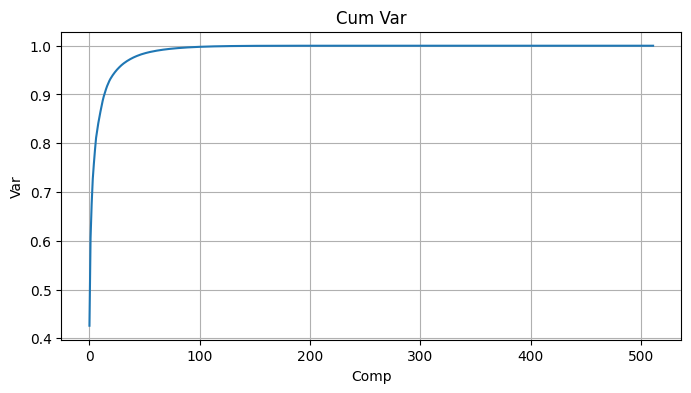

In [21]:
img = Image.open(c_path).convert('L')
arr = np.array(img, dtype=float)
h, w = arr.shape

x = arr.reshape(h, w)
mu = np.mean(x, axis=0)
x0 = x - mu
cov = np.cov(x0, rowvar=False)

ev, vec = np.linalg.eigh(cov)
ix = np.argsort(ev)[::-1]
ev = ev[ix]
vec = vec[:, ix]

vr = ev / np.sum(ev)
cv = np.cumsum(vr)

print('arr:', arr.shape)
print('x0:', x0.shape)
print('cov:', cov.shape)

plt.figure(figsize=(8, 4))
plt.plot(cv)
plt.title('Cum Var')
plt.xlabel('Comp')
plt.ylabel('Var')
plt.grid(True)
plt.show()


pc: (512, 50)
z: (512, 50)
rec: (512, 512)


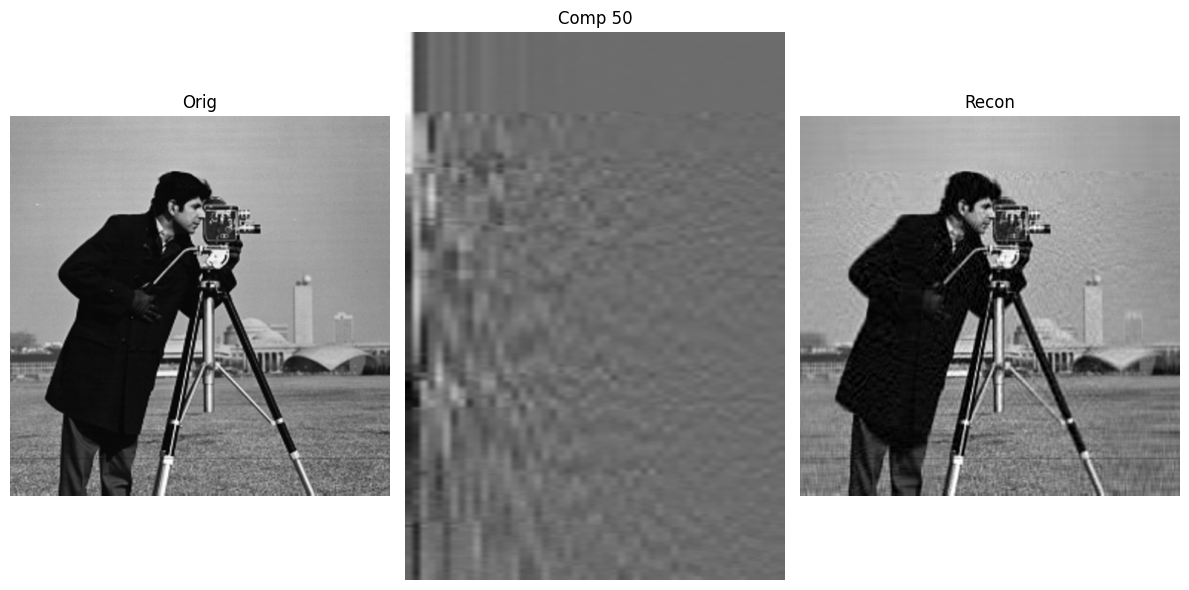

In [22]:
k = 50
pc = vec[:, :k]

z = np.dot(x0, pc)
rec = np.dot(z, pc.T) + mu
rec = np.clip(rec, 0, 255)

print('pc:', pc.shape)
print('z:', z.shape)
print('rec:', rec.shape)

plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
plt.imshow(arr, cmap='gray')
plt.title('Orig')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(z, cmap='gray', aspect='auto')
plt.title(f'Comp {k}')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(rec, cmap='gray')
plt.title('Recon')
plt.axis('off')

plt.tight_layout()
plt.show()


## Worksheet 1

In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image



c1 =  './cameraman.png'
g1 =  './lena_gray.gif'

print('c:', c1)
print('g:', g1)


c: ./cameraman.png
g: ./lena_gray.gif


### Qn 1

fmt: PNG
size: (512, 512)
mode: RGB
shape: (512, 512, 3)


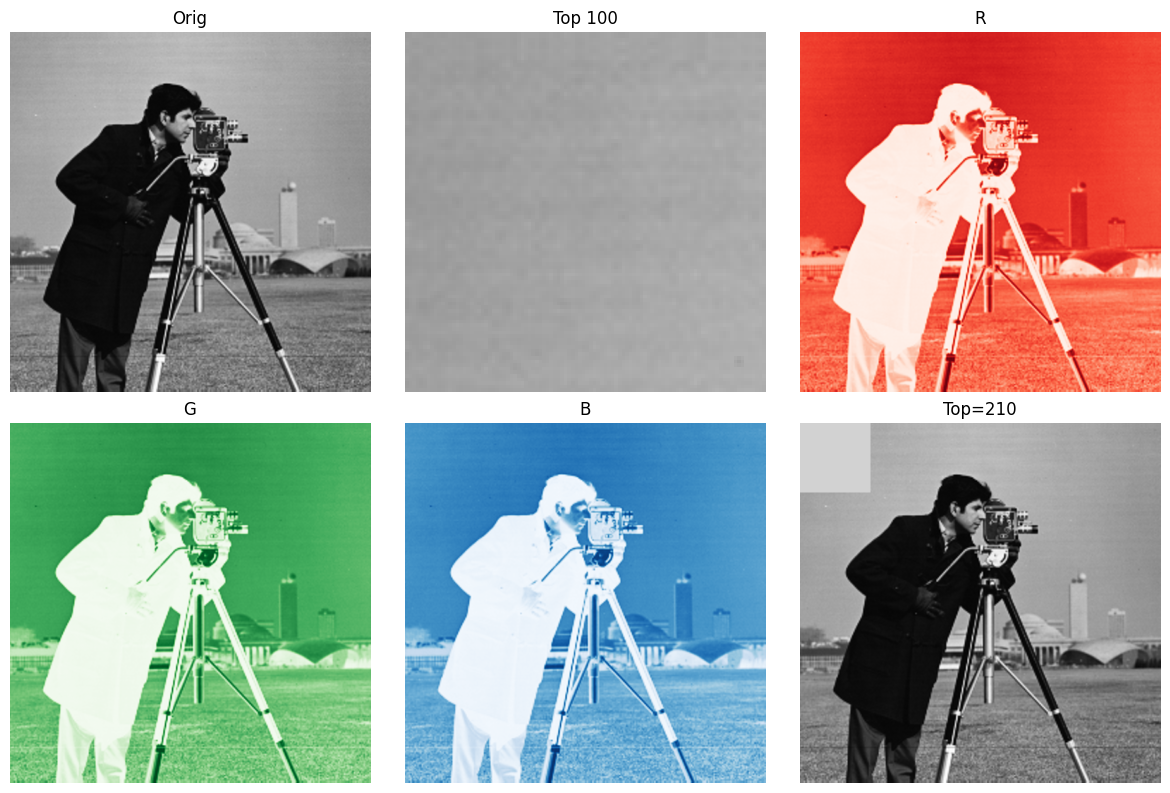

In [4]:
im0 = Image.open(c1)
im = im0.convert('RGB')
a = np.array(im)

print('fmt:', im0.format)
print('size:', im.size)
print('mode:', im.mode)
print('shape:', a.shape)

tl = a[:100, :100, :]

r = a[:, :, 0]
g = a[:, :, 1]
b = a[:, :, 2]

a2 = a.copy()
a2[:100, :100, :] = 210

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(a)
plt.title('Orig')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(tl)
plt.title('Top 100')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(r, cmap='Reds')
plt.title('R')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(g, cmap='Greens')
plt.title('G')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(b, cmap='Blues')
plt.title('B')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(a2)
plt.title('Top=210')
plt.axis('off')

plt.tight_layout()
plt.show()


### Qn 2

size: (512, 512)
mode: L
shape: (512, 512)


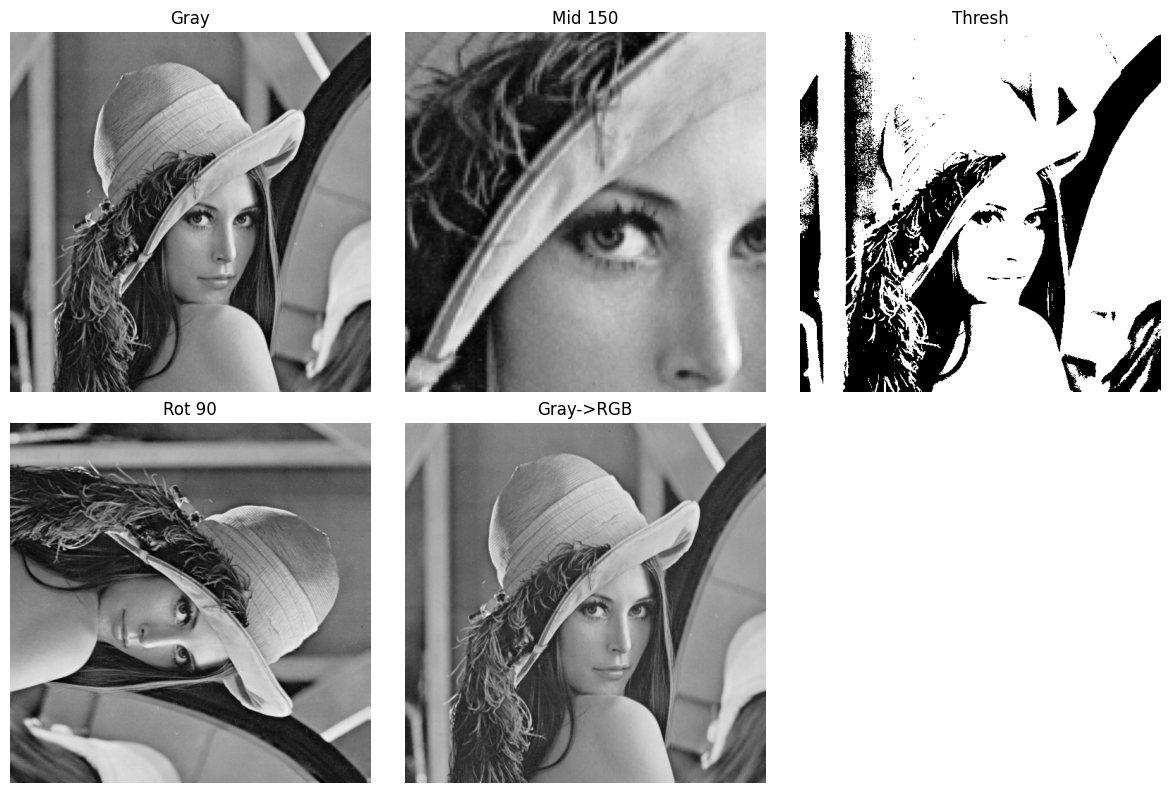

In [25]:
gim = Image.open(g1).convert('L')
ga = np.array(gim)

print('size:', gim.size)
print('mode:', gim.mode)
print('shape:', ga.shape)

h, w = ga.shape
m = 150
rs = (h - m) // 2
cs = (w - m) // 2
mid = ga[rs:rs + m, cs:cs + m]

bw = np.where(ga < 100, 0, 255).astype(np.uint8)
rot = np.array(gim.transpose(Image.Transpose.ROTATE_270))
rgb = np.stack((ga, ga, ga), axis=2)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(ga, cmap='gray')
plt.title('Gray')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(mid, cmap='gray')
plt.title('Mid 150')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(bw, cmap='gray')
plt.title('Thresh')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(rot, cmap='gray')
plt.title('Rot 90')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(rgb)
plt.title('Gray->RGB')
plt.axis('off')

plt.tight_layout()
plt.show()


### Qn 3

In [26]:
pim = Image.open(c1).convert('L')
d = np.array(pim, dtype=float)

mu = np.mean(d, axis=0)
d0 = d - mu
cov = np.cov(d0, rowvar=False)

print('d:', d.shape)
print('d0:', d0.shape)
print('cov:', cov.shape)


d: (512, 512)
d0: (512, 512)
cov: (512, 512)


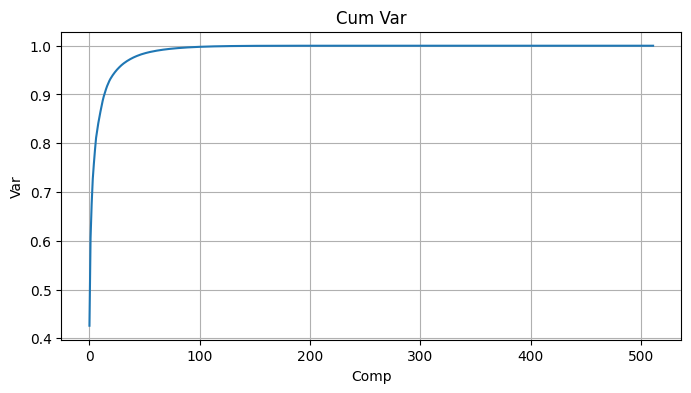

ev10:
[628073.69333443 264907.26821052 103581.57943132  75185.90733793
  46328.31857672  41295.65768877  36668.64879658  22477.47966576
  21783.80644109  18237.57267708]


In [27]:
ev, vec = np.linalg.eigh(cov)

ix = np.argsort(ev)[::-1]
ev = ev[ix]
vec = vec[:, ix]

vr = ev / np.sum(ev)
cv = np.cumsum(vr)

plt.figure(figsize=(8, 4))
plt.plot(cv)
plt.title('Cum Var')
plt.xlabel('Comp')
plt.ylabel('Var')
plt.grid(True)
plt.show()

print('ev10:')
print(ev[:10])


t | k | var | mse
0.80 | 7 | 0.811055 | 536.6962
0.90 | 15 | 0.903814 | 272.1081
0.95 | 26 | 0.950959 | 138.7117
0.99 | 63 | 0.990245 | 27.8579


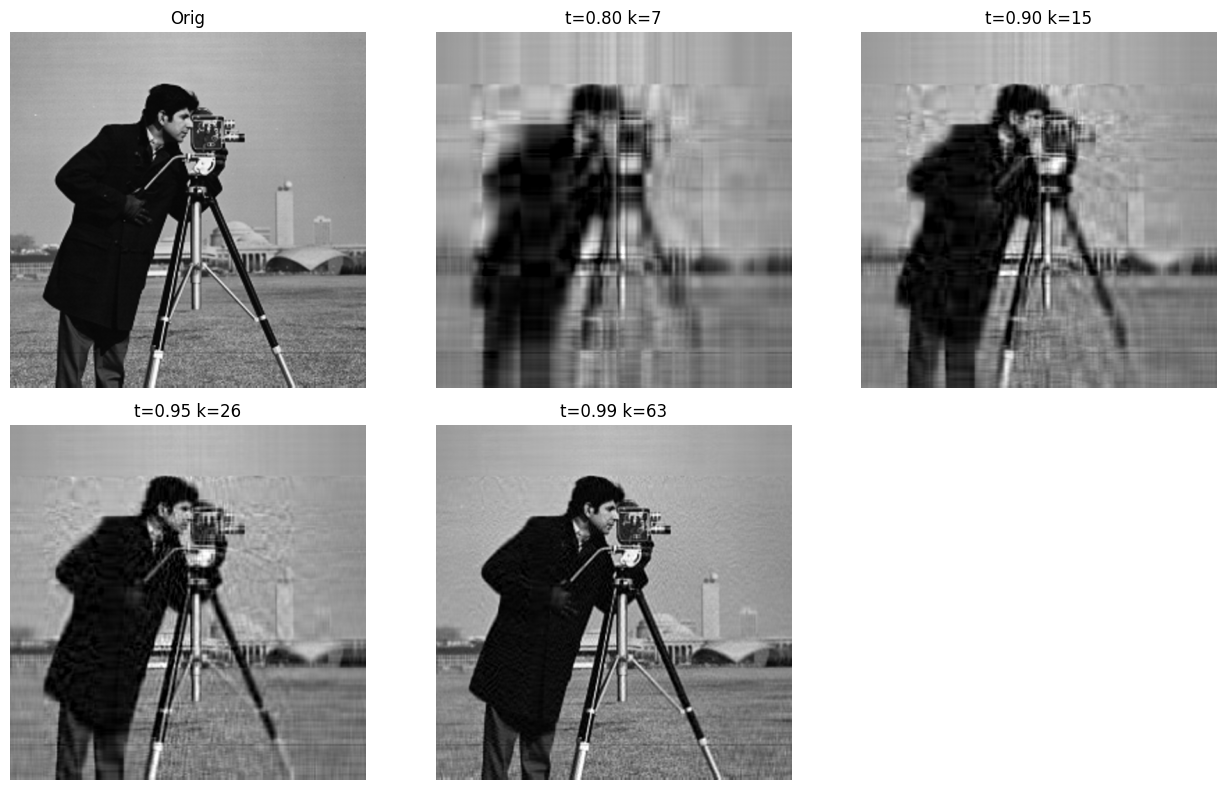

In [28]:
targets = [0.80, 0.90, 0.95, 0.99]
rows = []
recs = []

for t in targets:
    k = int(np.searchsorted(cv, t) + 1)
    pc = vec[:, :k]

    z = np.dot(d0, pc)
    r = np.dot(z, pc.T) + mu
    r = np.clip(r, 0, 255)

    mse = np.mean((d - r) ** 2)
    keep = cv[k - 1]

    rows.append((t, k, keep, mse))
    recs.append(r)

print('t | k | var | mse')
for row in rows:
    print(f'{row[0]:.2f} | {row[1]} | {row[2]:.6f} | {row[3]:.4f}')

plt.figure(figsize=(13, 8))
plt.subplot(2, 3, 1)
plt.imshow(d, cmap='gray')
plt.title('Orig')
plt.axis('off')

for i, (t, k, keep, mse) in enumerate(rows, start=2):
    plt.subplot(2, 3, i)
    plt.imshow(recs[i - 2], cmap='gray')
    plt.title(f't={t:.2f} k={k}')
    plt.axis('off')

plt.tight_layout()
plt.show()


### Qn 3 Result

- more var -> better image
- more var -> lower error